# 11. What the public data says about the IQVIA findings (DL-59, step 6)

**Question.** Do Medicare billing, Part B prices, Open Payments and Zilretta's company sales agree with what the IQVIA data told us (which specialties use Zilretta, where it is under-used, and what lines up with the 2022 turn)?

**Answer in one line.** The independent sources do **not** confirm the IQVIA specialty ranking (E1), they do confirm that Medicare adoption peaked in 2021 and eased by 2024 (E2a), they give a stable state ranking (E3), and company sales **rose** while IQVIA Zilretta visits fell by about half (E2b), which is the finding to take most seriously (notebook 12 shows that by full years the gap opens in 2023 and is largest in 2024, a year that overlaps the early-2024 IQVIA dip).

**How to read this notebook.** Every rule and threshold was written in [`docs/external_data_protocol.md`](../docs/external_data_protocol.md) before the data was analysed; the analyses are in `src/oa_market_intelligence/external/analysis/` and write one verdict row per rule to the local `gold_ext_verdicts` table. This notebook only **reads** those stored results and draws them; it fits nothing new except the provider-level plot in section 2. Everything here is association, never cause. Two of the tests are weakened or not clean, and the protocol says so (disclosures 1 and 5).

> **Runs only on the author's machine.** The external database (`data/processed/external.db`, about 134 MB) is git-ignored, so this notebook cannot run in CI; the outputs saved in the file are from the final run, whose id is printed in section 0.

In [1]:
import json
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path("..")
EXT = ROOT / "data" / "processed" / "external.db"
WH = ROOT / "data" / "published" / "warehouse.db"
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 110)
pd.set_option("display.max_rows", 200)

ext = sqlite3.connect(EXT)       # read only by convention
wh = sqlite3.connect(WH)

def q(sql, con=ext):
    return pd.read_sql(sql, con)

run_id = q("select max(run_id) r from gold_ext_verdicts").r[0]
verdicts = q(f"select check_id, metric, value, threshold, verdict, note, rule from gold_ext_verdicts where run_id = '{run_id}'")
print("final run:", run_id, "-", len(verdicts), "verdict rows")

final run: 20261008T043027Z-9fced37 - 37 verdict rows


## 0. Every verdict in one table

One row per pre-registered rule. *agrees / partial / disagrees* are for E1; *consistent / inconsistent* for E2; *usable / unstable* for E3; *supported / not_supported* for the E4 hypotheses (and for each lag of the H1 correlation); *not_run* is for E5, which only runs if H1 finds a significant lag.

In [2]:
order = {"E1": 0, "E2a": 1, "E2b": 2, "E3": 3, "H1": 4, "H2": 5, "H3": 6, "H4": 7, "E5": 8}
view = verdicts.assign(k=verdicts.check_id.map(order)).sort_values(["k", "metric"])
view[["check_id", "metric", "value", "threshold", "verdict"]].round(4).reset_index(drop=True)

,check_id,metric,value,threshold,verdict
0,E1,age65_rho,0.3818,>= 0.6,disagrees
1,E1,age65_top3_overlap,1.0000,>= 2 of 3,disagrees
2,E1,age65_verdict,NaN,NaN,disagrees
3,E1,no_osteopathic_rho,0.4182,>= 0.6,disagrees
4,E1,no_osteopathic_top3_overlap,1.0000,>= 2 of 3,disagrees
5,E1,no_osteopathic_verdict,NaN,NaN,disagrees
6,E1,rho,0.3455,>= 0.6,disagrees
7,E1,top3_overlap,1.0000,>= 2 of 3,disagrees
8,E1,verdict,NaN,NaN,disagrees
9,E2a,peak_year,2021.0000,"2021 or 2022, with 2024 below the peak",consistent


## 1. E1: does Medicare rank the specialties like IQVIA?

Medicare adoption = Zilretta (J3304) provider-years divided by provider-years of individuals billing at least one injectable-steroid code, by specialty group, 2020 to 2024 pooled; intervals resample providers (2,000 draws, seed 0). IQVIA's value is its adjusted share from the notebook-07 model, recomputed for the same years. **Rule:** agrees if rank correlation is at least 0.6 and at least two of the top three groups are shared.

In [3]:
tri = q("select * from gold_ext_specialty_triangulation where period = 'pooled_2020_2024'")
tri = tri.assign(medicare_pct=tri.medicare_adoption_rate * 100, lo=tri.medicare_ci_low * 100, hi=tri.medicare_ci_high * 100, iqvia_pct=tri.iqvia_adjusted_share * 100, iqvia_65_pct=tri.iqvia_share_65plus * 100)
tri = tri.sort_values("medicare_pct", ascending=False)
tri[["specialty_group", "relationship", "n_visible_providers", "n_zilretta_providers", "medicare_pct", "lo", "hi", "iqvia_pct", "iqvia_65_pct"]].round(2).reset_index(drop=True)

,specialty_group,relationship,n_visible_providers,n_zilretta_providers,medicare_pct,lo,hi,iqvia_pct,iqvia_65_pct
0,SPORTS MEDICINE,exact,5850,356,6.09,4.97,7.25,4.77,5.97
1,ORTHOPEDIC SURGERY,exact,68136,2812,4.13,3.86,4.43,2.27,2.78
2,PHYSICIAN ASSISTANT,exact,50500,1205,2.39,2.16,2.64,2.76,3.32
3,RHEUMATOLOGY,exact,11147,257,2.31,1.80,2.90,1.71,1.97
4,PHYSICAL MEDICINE & REHAB,exact,11516,194,1.68,1.30,2.13,5.49,6.78
5,PAIN MEDICINE,combined,11479,169,1.47,1.07,1.89,2.39,2.82
6,ANESTHESIOLOGY,exact,5450,69,1.27,0.79,1.82,3.10,2.89
7,OSTEOPATHIC MEDICINE,weak,299,3,1.00,0.00,2.76,3.10,3.81
8,NURSE PRACTITIONER,exact,45199,381,0.84,0.70,0.99,3.33,3.85
9,FAMILY PRACTICE,exact,45613,257,0.56,0.44,0.69,0.58,0.60


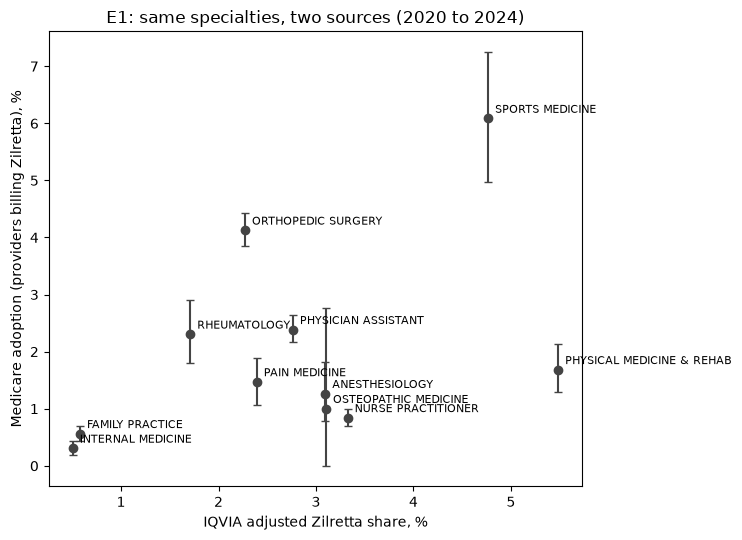

,metric,value,verdict,note
0,age65_rho,0.382,disagrees,95% interval 0.21 to 0.46 (11 groups). IQVIA restricted to patients aged 65 and over.
1,age65_top3_overlap,1.000,disagrees,"Medicare top 3: SPORTS MEDICINE, ORTHOPEDIC SURGERY, PHYSICIAN ASSISTANT; IQVIA top 3: PHYSICAL MEDICINE &..."
2,age65_verdict,NaN,disagrees,IQVIA restricted to patients aged 65 and over.
3,no_osteopathic_rho,0.418,disagrees,95% interval 0.32 to 0.50 (10 groups). Sensitivity: the weak crosswalk match (osteopathic medicine) removed.
4,no_osteopathic_top3_overlap,1.000,disagrees,"Medicare top 3: SPORTS MEDICINE, ORTHOPEDIC SURGERY, PHYSICIAN ASSISTANT; IQVIA top 3: PHYSICAL MEDICINE &..."
5,no_osteopathic_verdict,NaN,disagrees,Sensitivity: the weak crosswalk match (osteopathic medicine) removed.
6,rho,0.345,disagrees,"95% interval 0.18 to 0.44 (11 groups). All ages, IQVIA adjusted shares recomputed for 2020 to 2024."
7,top3_overlap,1.000,disagrees,"Medicare top 3: SPORTS MEDICINE, ORTHOPEDIC SURGERY, PHYSICIAN ASSISTANT; IQVIA top 3: PHYSICAL MEDICINE &..."
8,verdict,NaN,disagrees,"All ages, IQVIA adjusted shares recomputed for 2020 to 2024."


In [4]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))
t = tri.dropna(subset=["iqvia_pct"])
ax.errorbar(t.iqvia_pct, t.medicare_pct, yerr=[t.medicare_pct - t.lo, t.hi - t.medicare_pct], fmt="o", color="#444", capsize=3)
for _, r in t.iterrows():
    ax.annotate(r.specialty_group, (r.iqvia_pct, r.medicare_pct), textcoords="offset points", xytext=(5, 4), fontsize=8)
ax.set_xlabel("IQVIA adjusted Zilretta share, %")
ax.set_ylabel("Medicare adoption (providers billing Zilretta), %")
ax.set_title("E1: same specialties, two sources (2020 to 2024)")
plt.tight_layout()
plt.show()
verdicts[verdicts.check_id == "E1"][["metric", "value", "verdict", "note"]].round(3).reset_index(drop=True)

**Reading E1.** The two sources disagree: the rank correlation is about 0.35 against the 0.6 needed, and only one of the top three groups is shared. Two groups explain most of it. Physical Medicine and Rehabilitation is first in IQVIA but fifth in Medicare; sports medicine and orthopedics lead Medicare but not IQVIA. The result does not change when IQVIA is limited to patients aged 65 and over, or when the weakest crosswalk match (osteopathic medicine, three providers) is removed. We do not know which source is closer to the truth: Medicare shows who *bills* in Original Medicare (no diagnosis, one payer), IQVIA shows visits in its own panel, across all ages. **Do not read this as "IQVIA is wrong".** Read it as "the specialty ranking depends on the population".

## 2. E2a: did national adoption peak in 2021 or 2022 and fall by 2024?

*Weakened test (protocol disclosure 1): we had seen Medicare provider counts by year before writing this rule.*

In [5]:
import sys
sys.path.insert(0, str(ROOT / "src"))
from sqlalchemy import create_engine
from oa_market_intelligence.external.analysis.adoption import cluster_bootstrap_ci
from oa_market_intelligence.external.analysis.run_6a import load_provider_years

engine = create_engine(f"sqlite:///{EXT.as_posix()}")
py = load_provider_years(engine)
national = cluster_bootstrap_ci(py.assign(all="all"), "year")
national.assign(rate_pct=national.rate * 100, lo=national.low * 100, hi=national.high * 100)[["year", "n_provider_years", "n_zilretta", "rate_pct", "lo", "hi"]].round(2)

,year,n_provider_years,n_zilretta,rate_pct,lo,hi
0,2019,83955,908,1.08,1.01,1.15
1,2020,71836,1088,1.51,1.43,1.60
2,2021,72807,1293,1.78,1.68,1.87
3,2022,72845,1262,1.73,1.64,1.83
4,2023,74494,1180,1.58,1.50,1.67
5,2024,72978,1075,1.47,1.38,1.56


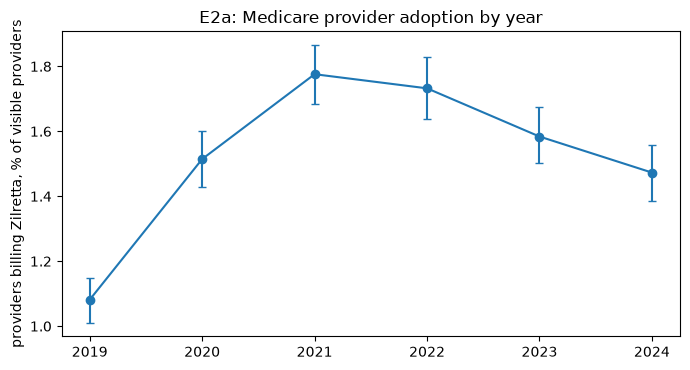

In [6]:
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.errorbar(national.year, national.rate * 100, yerr=[(national.rate - national.low) * 100, (national.high - national.rate) * 100], fmt="o-", color="#1f77b4", capsize=3)
ax.set_ylabel("providers billing Zilretta, % of visible providers")
ax.set_title("E2a: Medicare provider adoption by year")
ax.set_xticks(national.year)
plt.tight_layout()
plt.show()

**Reading E2a.** Adoption rose from 1.1% (2019) to 1.8% (2021), then eased to 1.5% (2024), a fall of about a sixth from the peak. This is consistent with the rule, and it is a much gentler decline than the one IQVIA shows. See section 6.

## 3. E3: where is Zilretta under-used?

A state-year is shown only with at least 30 visible providers. The ranking may be used only if the 2022 and 2024 state ranks correlate at 0.7 or more. *Headroom* = visible providers x (national adoption minus state adoption); a negative value means the state is above the national rate.

In [7]:
st = q("select * from gold_ext_state_adoption")
e3 = verdicts[verdicts.check_id == "E3"][["metric", "value", "verdict", "note"]].round(3)
print(e3.to_string(index=False))
d24 = st[(st.year == 2024) & (st.reported == 1)].sort_values("headroom", ascending=False)
cols = ["state_code", "n_visible_providers", "n_zilretta_providers", "adoption_rate", "ci_low", "ci_high", "ma_participation_rate", "arthritis_prevalence_pct", "headroom"]
print("\nlargest headroom, 2024")
display(d24[cols].head(10).round(4).reset_index(drop=True))
print("lowest headroom (highest adoption), 2024")
display(d24[cols].tail(8).round(4).reset_index(drop=True))

              metric  value verdict                                                                                      note
ma_adjusted_rank_rho  0.973  usable 2024, 51 states; top 5 shared: 5; rank correlation of adoption with Advantage share 0.05.
  rank_rho_2022_2024  0.921  usable    95% interval 0.77 to 0.94; 51 states with at least 30 visible providers in both years.

largest headroom, 2024


,state_code,n_visible_providers,n_zilretta_providers,adoption_rate,ci_low,ci_high,ma_participation_rate,arthritis_prevalence_pct,headroom
0,MI,1935,3,0.0016,0.0000,0.0036,0.6555,25.0668,25.4992
1,AZ,1915,5,0.0026,0.0005,0.0052,0.5468,21.7804,23.2046
2,FL,5331,59,0.0111,0.0083,0.0139,0.5974,21.5332,19.5164
3,MN,1066,0,0.0000,0.0000,0.0000,0.6400,19.3182,15.7003
4,IN,1569,12,0.0076,0.0038,0.0121,0.5261,25.3015,11.1087
5,SC,1688,15,0.0089,0.0047,0.0136,0.4812,24.4033,9.8613
6,LA,1635,15,0.0092,0.0049,0.0141,0.5972,26.5252,9.0807
7,VA,1890,19,0.0101,0.0058,0.0148,0.4181,23.3377,8.8364
8,NC,2771,32,0.0115,0.0076,0.0159,0.5898,23.8175,8.8120
9,CO,1129,8,0.0071,0.0027,0.0124,0.5680,21.3818,8.6282


lowest headroom (highest adoption), 2024


,state_code,n_visible_providers,n_zilretta_providers,adoption_rate,ci_low,ci_high,ma_participation_rate,arthritis_prevalence_pct,headroom
0,DE,199,14,0.0704,0.0402,0.1055,0.3400,23.3021,-11.0691
1,CA,5302,91,0.0172,0.0138,0.0207,0.5641,19.0329,-12.9107
2,NH,247,17,0.0688,0.0405,0.1012,0.3832,22.7604,-13.3621
3,MO,1253,34,0.0271,0.0184,0.0367,0.5686,25.2228,-15.5455
4,OK,1226,37,0.0302,0.0212,0.0400,0.4362,25.3585,-18.9431
5,PA,2678,59,0.0220,0.0168,0.0276,0.5758,NaN,-19.5577
6,MA,1107,49,0.0443,0.0334,0.0569,0.3879,22.2044,-32.6958
7,IL,2343,86,0.0367,0.0294,0.0444,0.4677,21.2922,-51.4917


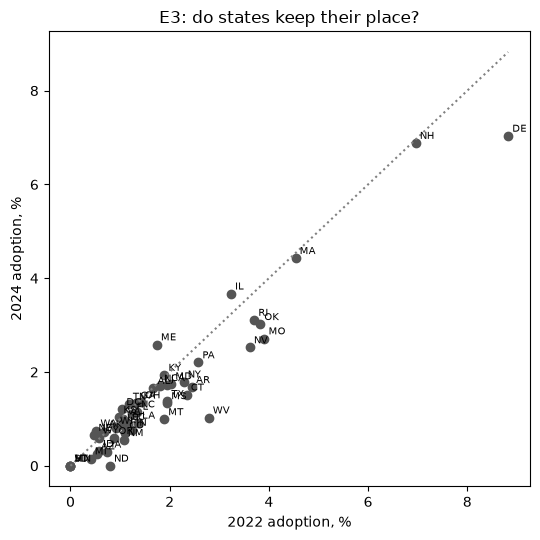

In [8]:
w = st[st.year.isin([2022, 2024])].pivot(index="state_code", columns="year", values="adoption_rate") * 100
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(w[2022], w[2024], color="#555")
for s, r in w.iterrows():
    ax.annotate(s, (r[2022], r[2024]), fontsize=7, xytext=(3, 3), textcoords="offset points")
m = float(max(w.max()))
ax.plot([0, m], [0, m], ":", color="gray")
ax.set_xlabel("2022 adoption, %")
ax.set_ylabel("2024 adoption, %")
ax.set_title("E3: do states keep their place?")
plt.tight_layout()
plt.show()

**Reading E3.** The states keep their place (rank correlation about 0.92, interval 0.77 to 0.94), so the ranking is **usable** under the rule. Removing the part of adoption that tracks Medicare Advantage share barely changes the ranking (0.97). Michigan, Arizona, Florida, Minnesota and Indiana have the most room; Illinois, Massachusetts, Pennsylvania, Oklahoma and Missouri are above the national rate. Three cautions. (1) **Stable is not the same as explained**: the same providers appear in both years, which raises the correlation (the paired bootstrap allows for this). (2) We have not looked into *why* Michigan or Minnesota are near zero; local Medicare coverage rules are one possibility and are **untested**. (3) This is Original Medicare only. Kentucky and Pennsylvania have no arthritis-prevalence value because the CDC file has no rows for them.

## 4. E4: what lines up with the 2022 turn?

Exploratory, association only. IQVIA's stored break is **March 2022**.

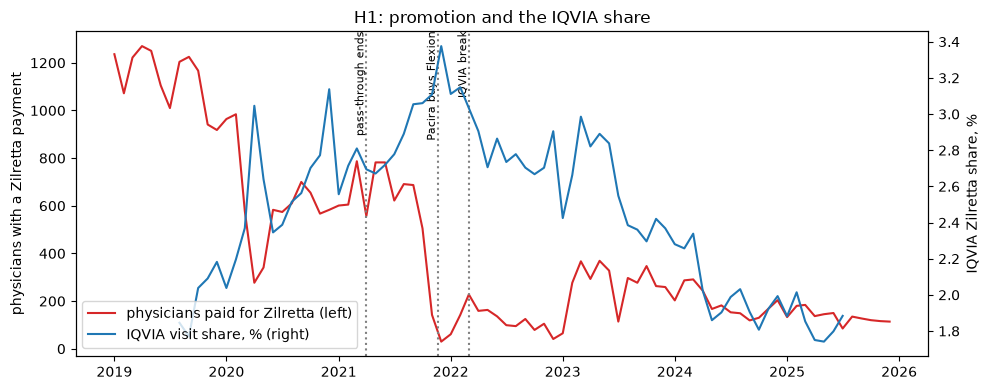

In [9]:
promo = q("select * from gold_ext_promotion_monthly order by month_id")
promo["date"] = pd.to_datetime(promo.month_id.astype(str), format="%Y%m")
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(promo.date, promo.n_physicians_paid, color="#d62728", label="physicians paid for Zilretta (left)")
ax.set_ylabel("physicians with a Zilretta payment")
ax2 = ax.twinx()
ax2.plot(promo.date, promo.iqvia_share_pct, color="#1f77b4", label="IQVIA visit share, % (right)")
ax2.set_ylabel("IQVIA Zilretta share, %")
for d, label in [("2021-03-31", "pass-through ends"), ("2021-11-19", "Pacira buys Flexion"), ("2022-03-01", "IQVIA break")]:
    ax.axvline(pd.Timestamp(d), color="gray", ls=":")
    ax.text(pd.Timestamp(d), ax.get_ylim()[1], label, rotation=90, va="top", ha="right", fontsize=8)
ax.set_title("H1: promotion and the IQVIA share")
fig.legend(loc="lower left", bbox_to_anchor=(0.08, 0.1))
plt.tight_layout()
plt.show()

                             metric  value   verdict                                                                                                                                                                                                                                                             note
sens_practitioners_worst_6mo_change -0.815 supported                                                                                                                                          Sensitivity. Practitioners are reported from January 2021, so only months from December 2021 can be tested (8 of them).
                   worst_6mo_change -0.813 supported Worst month 202204; 8 of 21 window months meet the rule, the first being 202112. Association only: Pacira closed its acquisition of Flexion on 19 November 2021, so a change of payer-of-record or reporting practice cannot be separated from a real pull-back.


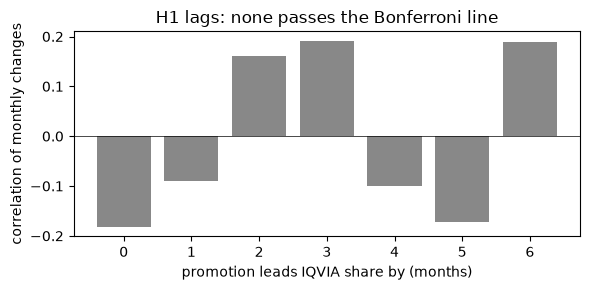

,lag,value,note
0,0,-0.183,"p = 0.2069. Physicians, IQVIA monthly visit share."
1,1,-0.091,"p = 0.5252. Physicians, IQVIA monthly visit share."
2,2,0.160,"p = 0.1544. Physicians, IQVIA monthly visit share."
3,3,0.192,"p = 0.1124. Physicians, IQVIA monthly visit share."
4,4,-0.100,"p = 0.3828. Physicians, IQVIA monthly visit share."
5,5,-0.172,"p = 0.3068. Physicians, IQVIA monthly visit share."
6,6,0.189,"p = 0.2244. Physicians, IQVIA monthly visit share."


In [10]:
h1 = verdicts[verdicts.check_id == "H1"]
print(h1[~h1.metric.str.contains("lag")][["metric", "value", "verdict", "note"]].round(3).to_string(index=False))
lags = h1[h1.metric.str.match(r"^lag\d_r$")].assign(lag=lambda d: d.metric.str[3].astype(int)).sort_values("lag")
fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(lags.lag, lags.value, color="#888")
ax.axhline(0, color="k", lw=0.5)
ax.set_xlabel("promotion leads IQVIA share by (months)")
ax.set_ylabel("correlation of monthly changes")
ax.set_title("H1 lags: none passes the Bonferroni line")
plt.tight_layout()
plt.show()
lags[["lag", "value", "note"]].round(3).reset_index(drop=True)

**Reading H1.** Physician payments tied to Zilretta fell sharply from November 2021, with the sharpest 6-month fall about 81% below the six months before, so the rule (a fall of at least 25%) is **supported**. The fall starts about four months before the IQVIA break. But (1) **no monthly lag passes the correction** (all p-values above 0.11), so the data does not show that promotion changes line up with share changes month by month; (2) the fall coincides with Pacira's purchase of Flexion (19 November 2021), so a real pull-back cannot be told apart from a change in who reports the payments; (3) E5, which would add promotion to the forecast, is therefore **skipped**.

In [11]:
price = q("select * from gold_ext_price_quarterly order by quarter_id")
display(price[price.quarter_id.between("2019Q3", "2022Q4")].round(4).reset_index(drop=True))
h2 = verdicts[verdicts.check_id == "H2"][["metric", "value", "verdict", "note"]]
display(h2.round(4))
verdicts[verdicts.check_id == "H3"][["metric", "value", "verdict", "note"]]

,quarter_id,j3304_limit_per_mg,j3301_limit_per_mg,price_ratio
0,2019Q3,18.881,0.1587,118.9729
1,2019Q4,18.880,0.1574,119.9492
2,2020Q1,18.880,0.1560,121.0256
3,2020Q2,18.634,0.1504,123.8963
4,2020Q3,18.313,0.1484,123.4030
5,2020Q4,18.204,0.1329,136.9752
6,2021Q1,18.006,0.1375,130.9527
7,2021Q2,17.887,0.1292,138.4443
8,2021Q3,17.996,0.1227,146.6667
9,2021Q4,17.748,0.1199,148.0234


,metric,value,verdict,note
30,price_ratio_change,0.1174,supported,Ratio 123.9 in 2020Q2 to 138.4 in 2021Q2. NOT A CLEAN TEST (protocol disclosure 5). The ratio moves becaus...


,metric,value,verdict,note
31,break_distance_months,11.0,not_supported,Stored break month 202203 against April 2021.


**Reading H2 and H3.** The Zilretta-to-triamcinolone price ratio rose 11.7% between 2020Q2 and 2021Q2, so the rule is met, **but this is not a clean test (protocol disclosure 5)** and the reason is not what the label suggests: the comparator's payment limit fell about 14% while Zilretta's fell about 4%; Zilretta did not get relatively more expensive in dollars. H3 (the end of pass-through status on 31 March 2021) is **not supported**: the detected break is 11 months later, outside the 6-month window. That was already decided by the existing result.

In [12]:
iq = q("select month_id, branded_injectable_visits b, generic_corticosteroid_visits g, nsaid_otc_visits n from gold_visit_share_monthly", wh).set_index("month_id")
rows = []
for m in range(3, 8):
    rows.append({"month": m, **{c: iq.loc[202400 + m, c] / iq.loc[202300 + m, c] - 1 for c in ["b", "g", "n"]}})
h4 = pd.DataFrame(rows).set_index("month")
h4.columns = ["Zilretta (branded injectable)", "generic corticosteroid", "NSAID and OTC"]
pooled = {c: iq.loc[202403:202407, k].sum() / iq.loc[202303:202307, k].sum() - 1 for c, k in zip(h4.columns, ["b", "g", "n"])}
display((h4 * 100).round(1))
print("pooled March to July:", {k: f"{v:+.1%}" for k, v in pooled.items()})
verdicts[verdicts.check_id == "H4"][["metric", "value", "verdict"]].round(3)

,Zilretta (branded injectable),generic corticosteroid,NSAID and OTC
month,,,
3,-45.6,-30.0,-30.5
4,-41.6,-18.5,-10.4
5,-53.1,-26.9,-19.0
6,-53.8,-31.7,-14.5
7,-35.4,-17.9,-2.3


pooled March to July: {'Zilretta (branded injectable)': '-46.6%', 'generic corticosteroid': '-25.3%', 'NSAID and OTC': '-15.9%'}


,metric,value,verdict
32,all_three_below,NaN,supported
33,branded_injectable_visits_change,-0.466,supported
34,generic_corticosteroid_visits_change,-0.253,supported
35,months_all_three_below,4.000,not_supported
36,nsaid_otc_visits_change,-0.159,supported


**Reading H4.** Pooled over March to July 2024, all three IQVIA categories are at least 10% below the same months of 2023, so the rule for "consistent with a data-capture problem" is **met**. Two reasons not to lean on it. The protocol did not say whether to pool the months; taken **one month at a time**, the rule fails in July (NSAID and OTC visits are down only 2%), so the verdict depends on the reading. And the sizes differ widely (Zilretta about -47%, corticosteroids -25%, NSAID and OTC -16%): a capture problem that hit everything equally would not produce that spread, so it cannot explain the whole Zilretta fall.

## 5. E2b: do the company's sales move with IQVIA's Zilretta visits?

*Weakened test (disclosure 1). Sales are national and all-payer.* Flexion reported to Q3 2021, Pacira from Q1 2022 (Q4 2021 is a derived figure spanning the acquisition). A quarter agrees when the year-on-year direction (up, down or flat within 1%) is the same. IQVIA starts in August 2019, so Q3 2020 is compared on August and September only.

In [13]:
cv = q("select * from gold_ext_company_vs_visits order by quarter_id")
display(cv[["quarter_id", "company", "net_sales_usd", "iqvia_zilretta_visits", "yoy_sales_direction", "yoy_visits_direction", "directions_agree"]])
print("agree:", int(cv.directions_agree.sum()), "of", int(cv.directions_agree.notna().sum()))

,quarter_id,company,net_sales_usd,iqvia_zilretta_visits,yoy_sales_direction,yoy_visits_direction,directions_agree
0,2020Q3,Flexion Therapeutics,23664000.0,5201,up,up,1
1,2020Q4,Flexion Therapeutics,26310000.0,5770,up,up,1
2,2021Q1,Flexion Therapeutics,24589000.0,5541,up,up,1
3,2021Q2,Flexion Therapeutics,28175000.0,7118,up,up,1
4,2021Q3,Flexion Therapeutics,21326000.0,7250,down,up,0
5,2021Q4,Flexion Therapeutics and Pacira BioSciences,28610000.0,7683,up,up,1
6,2022Q1,Pacira BioSciences,23635000.0,7434,down,up,0
7,2022Q2,Pacira BioSciences,27417000.0,7850,down,up,0
8,2022Q3,Pacira BioSciences,26494000.0,7288,up,flat,0
9,2022Q4,Pacira BioSciences,27971000.0,6877,down,down,1


agree: 9 of 20


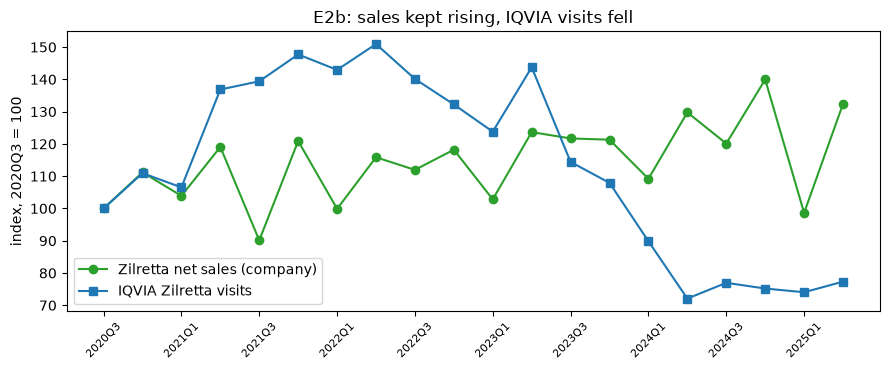

In [14]:
fig, ax = plt.subplots(figsize=(9, 3.8))
x = np.arange(len(cv))
idx = lambda s: s / s.iloc[0] * 100
ax.plot(x, idx(cv.net_sales_usd), "o-", color="#2ca02c", label="Zilretta net sales (company)")
ax.plot(x, idx(cv.iqvia_zilretta_visits), "s-", color="#1f77b4", label="IQVIA Zilretta visits")
ax.set_xticks(x[::2])
ax.set_xticklabels(cv.quarter_id.iloc[::2], rotation=45, fontsize=8)
ax.set_ylabel("index, 2020Q3 = 100")
ax.legend()
ax.set_title("E2b: sales kept rising, IQVIA visits fell")
plt.tight_layout()
plt.show()

**Reading E2b.** Direction agrees in only 9 of 20 quarters (45%) against the 70% needed, so the result is **inconsistent**. Through 2021 they mostly move together; in direction they disagree from 2022, and in size from 2023: company net sales are higher in 2025 than in 2022 while IQVIA Zilretta visits are down by about half. Medicare adoption (E2a) eased only by about a sixth. Three explanations are open and **none has been tested**: IQVIA's panel lost coverage of Zilretta settings; the number of visits fell but each visit became worth more (price, units per visit or mix); or sales and visits measure different payers. Correction made after notebook 12: an earlier version of this sentence said the 2024 capture issue (H4) could not explain the gap. By full years the gap opens in 2023 (IQVIA visits -14%, sales +5%) and is largest in 2024 (-36% against +6%), a year that overlaps the early-2024 dip, so a 2024 capture or coverage problem is a live possibility (untested; see notebook 12).

## 6. What this means, and what it does not

| | Result | What to take from it |
|---|---|---|
| E1 specialty ranking | disagrees | the ranking depends on the population; do not present the IQVIA specialty order as a market fact |
| E2a Medicare trend | consistent (weak test) | adoption peaked 2021 and eased; much milder than IQVIA's fall |
| E2b sales vs visits | inconsistent (weak test) | **the IQVIA level decline is not confirmed by company sales; investigate before quoting it** |
| E3 state ranks | usable | a stable list of states with room; a starting list, not a forecast of what a campaign would win |
| H1 promotion | supported; no lag | promotion fell before the turn; no month-by-month link; confounded by the acquisition |
| H2 price | supported (not clean) | driven by the comparator's price fall, not by Zilretta getting dearer |
| H3 pass-through | not supported | decided by the existing break |
| H4 2024 dip | met when pooled; fails month by month | a capture problem may contribute; cannot explain it all |
| E5 | skipped | no significant lag |

None of this is causal. Original Medicare is a different population from IQVIA's panel, and several tests are weakened or not clean, as stated in the protocol.

In [15]:
# Reproducibility: the final run was done twice; the two verdict tables are identical.
runs = q("select distinct run_id from gold_ext_verdicts order by run_id").run_id.tolist()
a, b = runs[-2], runs[-1]
cols = ["check_id", "metric", "value", "verdict"]
ta = q(f"select {','.join(cols)} from gold_ext_verdicts where run_id = '{a}' order by check_id, metric")
tb = q(f"select {','.join(cols)} from gold_ext_verdicts where run_id = '{b}' order by check_id, metric")
print(a, b, "identical:", ta.equals(tb), "rows:", len(ta))

20261008T042537Z-9fced37 20261008T043027Z-9fced37 identical: True rows: 37
